# Analiza rynku mieszkań w Warszawie
EDA i detekcja outlierów — zbiór 2000 ofert

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

np.random.seed(42)

n = 2000
dzielnice = ["Mokotów", "Wola", "Śródmieście", "Praga-Południe", "Ursynów",
             "Bemowo", "Białołęka", "Targówek", "Bielany", "Ochota", "Wilanów"]
multiplikator_dzielnicy = {
    "Mokotów": 1.15, "Wola": 1.10, "Śródmieście": 1.40, "Praga-Południe": 0.90,
    "Ursynów": 1.00, "Bemowo": 0.95, "Białołęka": 0.85, "Targówek": 0.88,
    "Bielany": 0.95, "Ochota": 1.05, "Wilanów": 1.20
}

dzielnica = np.random.choice(dzielnice, n)
metraz = np.clip(np.random.normal(55, 22, n), 18, 180)
pokoje = np.clip(np.round(metraz / 18 + np.random.normal(0, 0.5, n)), 1, 6).astype(int)
pietro = np.random.randint(0, 12, n)
rok_budowy = np.random.choice(
    list(range(1950, 2025)),
    n,
    p=np.linspace(0.5, 2, 75) / np.linspace(0.5, 2, 75).sum()
)
ma_balkon = np.random.choice([True, False], n, p=[0.75, 0.25])
ma_miejsce_parkingowe = np.random.choice([True, False], n, p=[0.45, 0.55])
odleglosc_od_centrum = np.clip(np.random.gamma(2.5, 2.5, n), 0.5, 25)

cena_za_m2 = (
    14000
    * np.array([multiplikator_dzielnicy[d] for d in dzielnica])
    * (1 + 0.005 * (rok_budowy - 1980))
    * (1 - 0.015 * odleglosc_od_centrum)
    * (1 + 0.05 * ma_balkon)
    * (1 + 0.08 * ma_miejsce_parkingowe)
    + np.random.normal(0, 1500, n)
)
cena = (cena_za_m2 * metraz).round(0)

df = pd.DataFrame({
    "id_oferty": range(10001, 10001 + n),
    "dzielnica": dzielnica,
    "metraz_m2": metraz.round(1),
    "liczba_pokoi": pokoje,
    "pietro": pietro,
    "rok_budowy": rok_budowy,
    "ma_balkon": ma_balkon,
    "ma_miejsce_parkingowe": ma_miejsce_parkingowe,
    "odleglosc_od_centrum_km": odleglosc_od_centrum.round(2),
    "cena_pln": cena
})

# outliery i bledy - dokladnie jak na stronie
outlier_idx = np.random.choice(df.index, 30, replace=False)
df.loc[outlier_idx[:10], "cena_pln"] *= np.random.uniform(5, 12, 10)
df.loc[outlier_idx[10:20], "cena_pln"] *= np.random.uniform(0.05, 0.2, 10)
df.loc[outlier_idx[20:25], "metraz_m2"] = np.random.uniform(300, 600, 5)
df.loc[outlier_idx[25:30], "rok_budowy"] = np.random.choice([1800, 1850, 2050, 2099], 5)

df.to_csv("mieszkania_warszawa.csv", index=False)
print(f"Wygenerowano plik 'mieszkania_warszawa.csv' — {len(df)} ofert")

Wygenerowano plik 'mieszkania_warszawa.csv' — 2000 ofert


## Część 1: Wstępna eksploracja

In [2]:
df = pd.read_csv("mieszkania_warszawa.csv")

print("=== shape ===")
print(df.shape)

print("\n=== info ===")
df.info()

=== shape ===
(2000, 10)

=== info ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_oferty                2000 non-null   int64  
 1   dzielnica                2000 non-null   str    
 2   metraz_m2                2000 non-null   float64
 3   liczba_pokoi             2000 non-null   int64  
 4   pietro                   2000 non-null   int64  
 5   rok_budowy               2000 non-null   int64  
 6   ma_balkon                2000 non-null   bool   
 7   ma_miejsce_parkingowe    2000 non-null   bool   
 8   odleglosc_od_centrum_km  2000 non-null   float64
 9   cena_pln                 2000 non-null   float64
dtypes: bool(2), float64(3), int64(4), str(1)
memory usage: 129.0 KB


In [3]:
print("=== describe ===")
df.describe()

=== describe ===


,id_oferty,metraz_m2,liczba_pokoi,pietro,rok_budowy,odleglosc_od_centrum_km,cena_pln
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,11000.500000,56.965758,3.085500,5.415500,1993.889500,6.222265,8.809612e+05
std,577.494589,30.787760,1.264907,3.501998,21.076632,3.909166,7.499763e+05
min,10001.000000,18.000000,1.000000,0.000000,1800.000000,0.500000,6.177632e+04
25%,10500.750000,40.800000,2.000000,2.000000,1979.000000,3.350000,5.685120e+05
50%,11000.500000,55.350000,3.000000,5.000000,1997.000000,5.550000,8.095755e+05
75%,11500.250000,69.900000,4.000000,8.000000,2011.000000,8.322500,1.070190e+06
max,12000.000000,585.187341,6.000000,11.000000,2050.000000,25.000000,2.292390e+07


In [4]:
print("=== brakujące wartości ===")
print(df.isnull().sum())

# podejrzane wartosci:
# - cena_pln: min i max bardzo odbiegają od mediany - widać outliery
# - metraz_m2: max 600 m2 to zdecydowanie outlier albo blad
# - rok_budowy: min ponizej 1900 lub max powyzej 2026 to bledy danych

=== brakujące wartości ===
id_oferty                  0
dzielnica                  0
metraz_m2                  0
liczba_pokoi               0
pietro                     0
rok_budowy                 0
ma_balkon                  0
ma_miejsce_parkingowe      0
odleglosc_od_centrum_km    0
cena_pln                   0
dtype: int64


## Część 2: Statystyki opisowe

In [5]:
print("=== cena_pln ===")
print(f"Średnia:          {df['cena_pln'].mean():.2f}")
print(f"Mediana:          {df['cena_pln'].median():.2f}")
print(f"Odchylenie std:   {df['cena_pln'].std():.2f}")
print(f"Skewness:         {df['cena_pln'].skew():.4f}")
print(f"Kurtosis:         {df['cena_pln'].kurt():.4f}")

print("\n=== metraz_m2 ===")
q1 = df["metraz_m2"].quantile(0.25)
q3 = df["metraz_m2"].quantile(0.75)
iqr = q3 - q1
print(f"Q1:  {q1:.2f}")
print(f"Q3:  {q3:.2f}")
print(f"IQR: {iqr:.2f}")

print("\n=== dzielnice ===")
print(df["dzielnica"].value_counts())

=== cena_pln ===
Średnia:          880961.21
Mediana:          809575.50
Odchylenie std:   749976.28
Skewness:         15.8584
Kurtosis:         404.2183

=== metraz_m2 ===
Q1:  40.80
Q3:  69.90
IQR: 29.10

=== dzielnice ===
dzielnica
Mokotów           210
Targówek          189
Ursynów           189
Śródmieście       189
Ochota            188
Wola              178
Białołęka         177
Bemowo            176
Bielany           174
Praga-Południe    166
Wilanów           164
Name: count, dtype: int64


Skewness ceny wynosi **15.86** — silna skośność prawostronna. Oznacza to, że większość ofert skupia się poniżej średniej, a rozkład ma długi ogon w prawo przez ekstremalne, drogie outliery. Dlatego **mediana (809 tys. PLN) lepiej opisuje typową cenę** niż średnia (880 tys. PLN). Kurtosis 404 potwierdza, że ogon jest bardzo ciężki — kilka skrajnych wartości mocno zawyża statystyki.

## Część 3: Wizualizacja jednowymiarowa

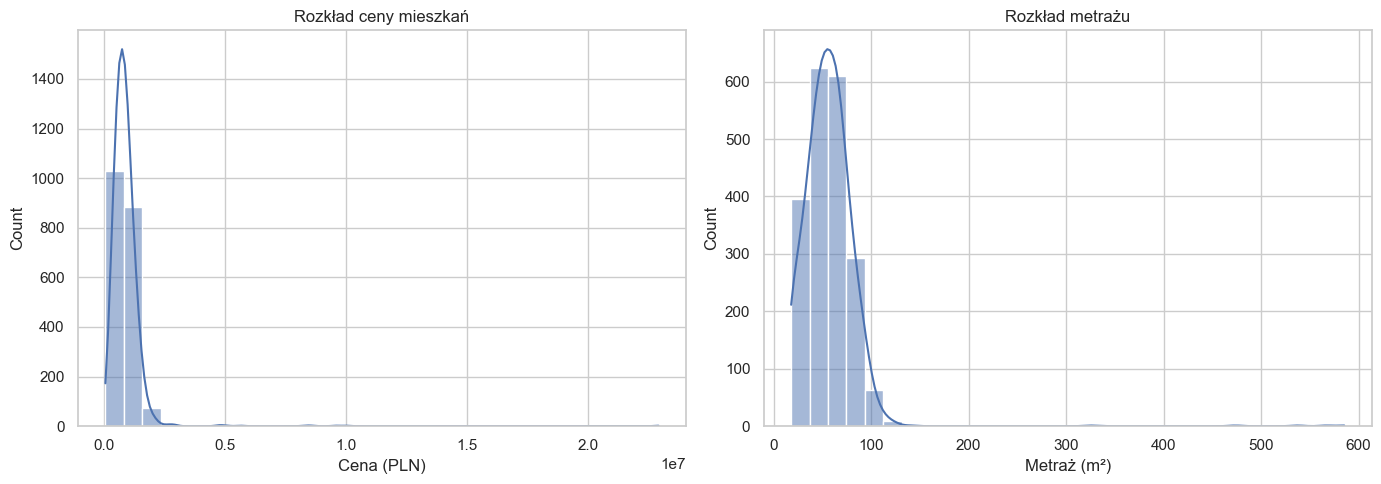

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["cena_pln"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Rozkład ceny mieszkań")
axes[0].set_xlabel("Cena (PLN)")
sns.histplot(df["metraz_m2"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Rozkład metrażu")
axes[1].set_xlabel("Metraż (m²)")
plt.tight_layout()
plt.show()

**Ocena skośności histogramów:**

- **Cena:** rozkład wyraźnie prawostronny — widoczny długi ogon po prawej. Większość mieszkań kosztuje 500–900 tys. PLN, ale pojedyncze oferty sięgają kilkunastu milionów.
- **Metraż:** rozkład zbliżony do normalnego, lekko prawostronny. Dominują mieszkania 35–80 m², widoczne outliery powyżej 300 m².

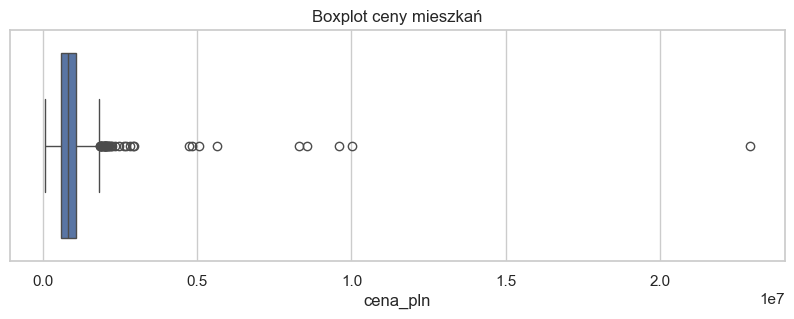

In [7]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["cena_pln"])
plt.title("Boxplot ceny mieszkań")
plt.show()

**Obserwacje z boxplotu ceny:**

- Pudełko (Q1–Q3) mieści się w zakresie ok. 560–1 070 tys. PLN, co oznacza, że środkowe 50% ofert różni się ceną o ok. 500 tys. PLN.
- Liczne kropki po prawej to outliery — ceny wielokrotnie przekraczające górną granicę wąsów.
- Brak outlierów po lewej stronie (nie ma cen nienaturalnie niskich).
- Rozkład jest silnie asymetryczny — linia mediany jest wyraźnie przesunięta w lewo względem środka pudełka.

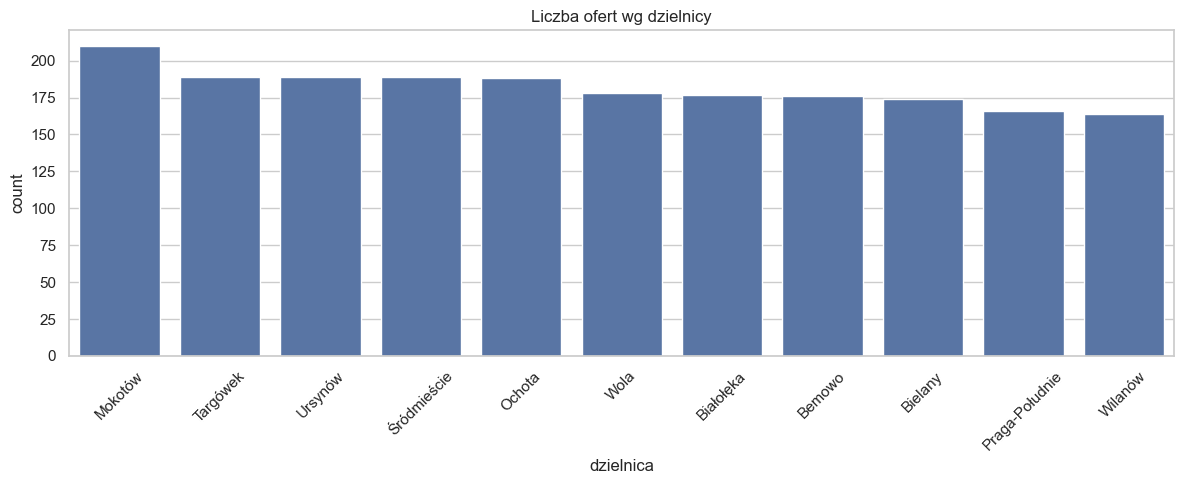

In [8]:
# posortowane malejąco wg liczby ofert
order = df["dzielnica"].value_counts().index
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="dzielnica", order=order)
plt.title("Liczba ofert wg dzielnicy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Część 4: Analiza zależności

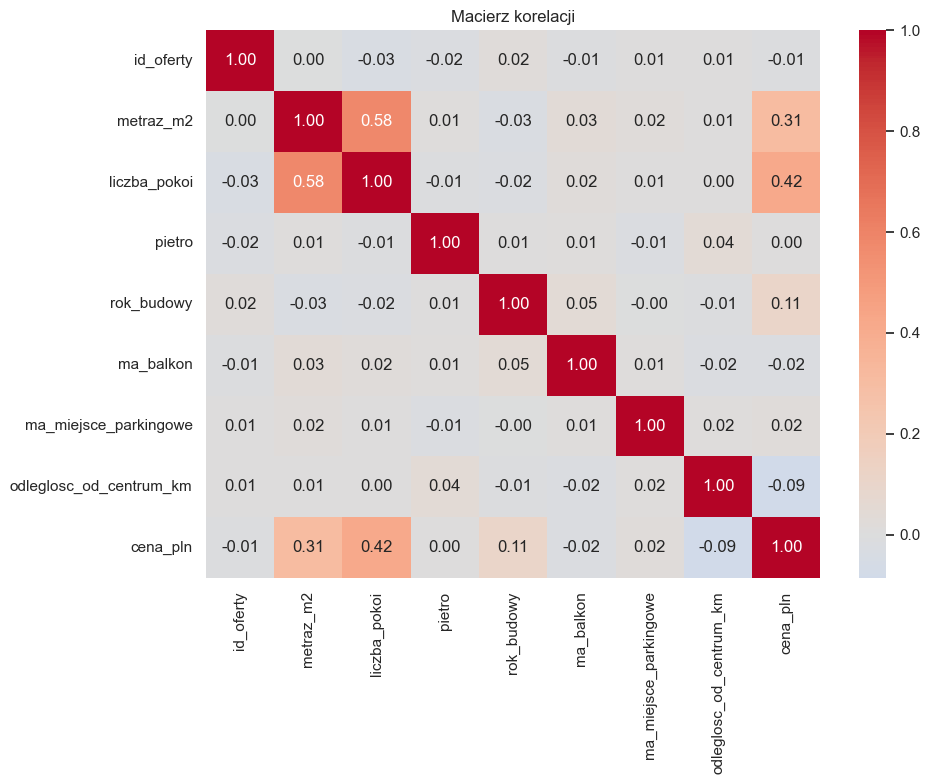

Korelacja z cena_pln:
liczba_pokoi               0.419491
metraz_m2                  0.310040
rok_budowy                 0.105799
odleglosc_od_centrum_km    0.086266
ma_miejsce_parkingowe      0.017515
ma_balkon                  0.016987
id_oferty                  0.012569
pietro                     0.004495
Name: cena_pln, dtype: float64


In [9]:
# rzutuje bool na int bo inaczej nie liczy korelacji
df_corr = df.copy()
df_corr["ma_balkon"] = df_corr["ma_balkon"].astype(int)
df_corr["ma_miejsce_parkingowe"] = df_corr["ma_miejsce_parkingowe"].astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_corr.select_dtypes(include="number").corr(),
    annot=True, cmap="coolwarm", center=0, fmt=".2f"
)
plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()

# która zmienna najsilniej związana z ceną
korelacje = df_corr.select_dtypes(include="number").corr()["cena_pln"].drop("cena_pln").abs().sort_values(ascending=False)
print("Korelacja z cena_pln:")
print(korelacje)

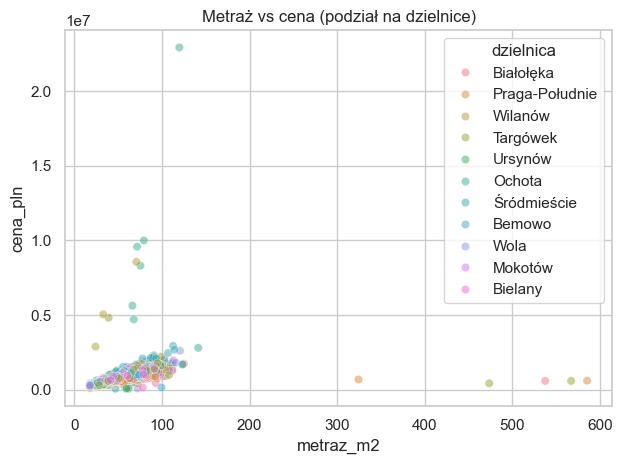

In [10]:
sns.scatterplot(data=df, x="metraz_m2", y="cena_pln", hue="dzielnica", alpha=0.5)
plt.title("Metraż vs cena (podział na dzielnice)")
plt.tight_layout()
plt.show()

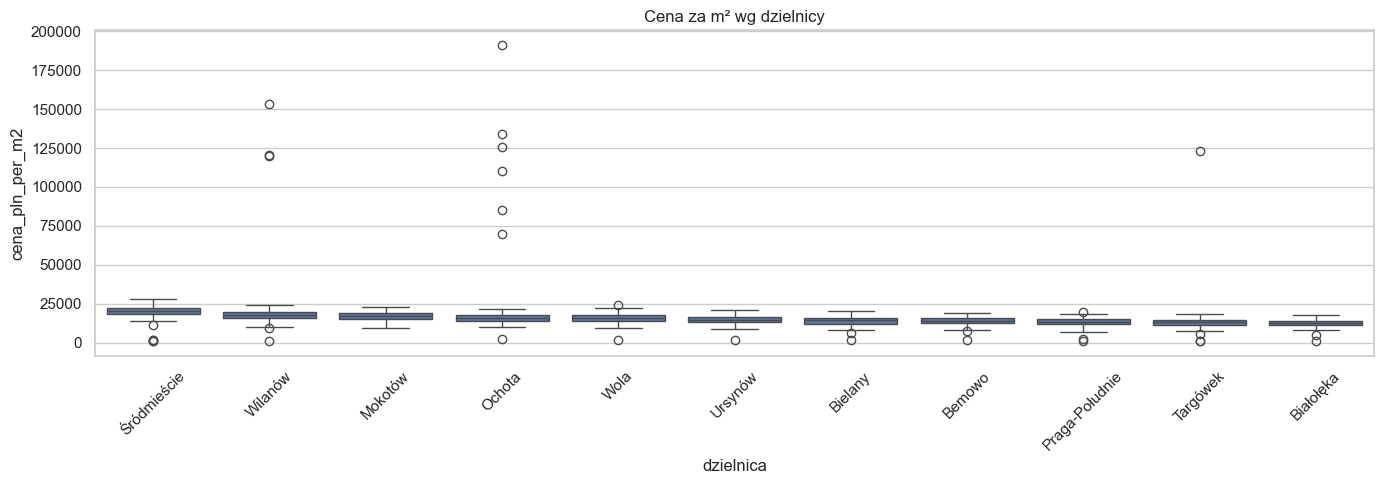

In [11]:
df["cena_pln_per_m2"] = df["cena_pln"] / df["metraz_m2"]

# sortuję po medianie ceny za m2 zeby bylo czytelnie
order_med = df.groupby("dzielnica")["cena_pln_per_m2"].median().sort_values(ascending=False).index
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x="dzielnica", y="cena_pln_per_m2", order=order_med)
plt.title("Cena za m² wg dzielnicy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Część 5: Detekcja outlierów

In [12]:
# metoda 1: IQR - funkcja z materiałów z zajęć
def outliers_iqr(series, mnoznik=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    dolna = Q1 - mnoznik * IQR
    gorna = Q3 + mnoznik * IQR
    return (series < dolna) | (series > gorna)

m_iqr = outliers_iqr(df["cena_pln"])
print(f"IQR (1.5×):       {m_iqr.sum()} outlierów ({m_iqr.mean()*100:.1f}%)")

# metoda 2: Z-score
z = stats.zscore(df["cena_pln"], nan_policy="omit")
m_z = np.abs(z) > 3
print(f"Z-score (|z|>3):  {m_z.sum()} outlierów")

# metoda 3: Modified Z-score (MAD) - odporna na ekstremalne wartosci
def modified_zscore(series):
    mediana = series.median()
    mad = (series - mediana).abs().median()
    return 0.6745 * (series - mediana) / mad

z_mod = modified_zscore(df["cena_pln"])
m_mod = np.abs(z_mod) > 3.5
print(f"Mod Z (>3.5):     {m_mod.sum()} outlierów")

IQR (1.5×):       39 outlierów (1.9%)
Z-score (|z|>3):  9 outlierów
Mod Z (>3.5):     22 outlierów


In [13]:
# outliery metrazu - metoda IQR, top 5
m_metraz = outliers_iqr(df["metraz_m2"])
print(f"Outlierów metrażu: {m_metraz.sum()}")
print("\nTop 5 największych metraży:")
print(df[m_metraz].nlargest(5, "metraz_m2")[["id_oferty", "dzielnica", "metraz_m2", "cena_pln"]])

Outlierów metrażu: 13

Top 5 największych metraży:
      id_oferty       dzielnica   metraz_m2  cena_pln
1597      11598  Praga-Południe  585.187341  614202.0
1845      11846        Targówek  566.921693  593446.0
53        10054       Białołęka  537.356930  595626.0
1681      11682        Targówek  473.491995  436705.0
1050      11051  Praga-Południe  324.358377  693470.0


In [14]:
# bledy w roku budowy
bledy_rok = df[(df["rok_budowy"] < 1900) | (df["rok_budowy"] > 2026)]
print(f"Błędy w rok_budowy: {len(bledy_rok)} wierszy")
print(bledy_rok[["id_oferty", "rok_budowy", "dzielnica"]])

Błędy w rok_budowy: 5 wierszy
      id_oferty  rok_budowy       dzielnica
237       10238        1850        Targówek
557       10558        2050         Ursynów
635       10636        1800  Praga-Południe
1030      11031        2050  Praga-Południe
1954      11955        1800         Wilanów


## Część 6: Czyszczenie danych

In [15]:
df_clean = df[(df["rok_budowy"] >= 1900) & (df["rok_budowy"] <= 2026)].copy()
print(f"Po usunięciu błędnych lat budowy: {len(df_clean)} wierszy (było {len(df)})")

Po usunięciu błędnych lat budowy: 1995 wierszy (było 2000)


In [16]:
# winsoryzacja - przycinam do 1 i 99 percentyla
gorna_granica = df_clean["cena_pln"].quantile(0.99)
dolna_granica = df_clean["cena_pln"].quantile(0.01)
df_clean["cena_pln_capped"] = df_clean["cena_pln"].clip(lower=dolna_granica, upper=gorna_granica)

df_clean["cena_pln_log"] = np.log1p(df_clean["cena_pln"])

print(f"Skewness przed:          {df_clean['cena_pln'].skew():.2f}")
print(f"Skewness po winsoryzacji: {df_clean['cena_pln_capped'].skew():.2f}")
print(f"Skewness log(1+cena):    {df_clean['cena_pln_log'].skew():.2f}")

Skewness przed:          15.86
Skewness po winsoryzacji: 0.75
Skewness log(1+cena):    -0.24


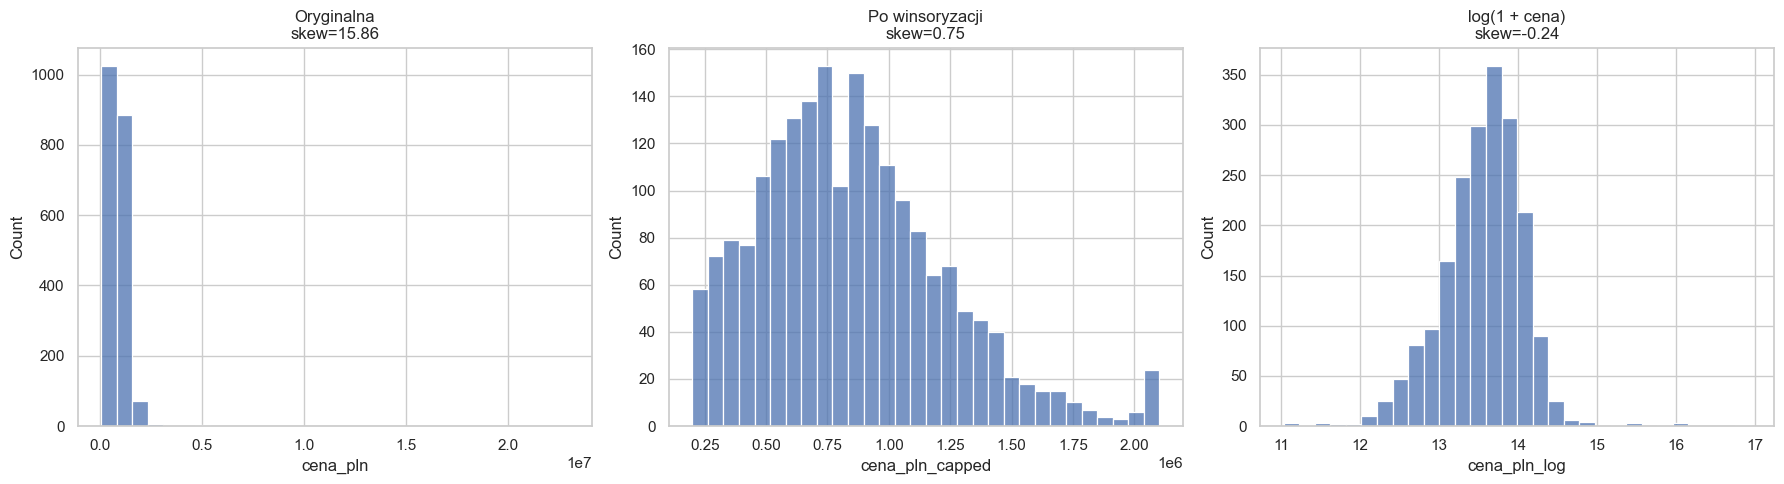

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_clean["cena_pln"], bins=30, ax=axes[0])
axes[0].set_title(f"Oryginalna\nskew={df_clean['cena_pln'].skew():.2f}")
sns.histplot(df_clean["cena_pln_capped"], bins=30, ax=axes[1])
axes[1].set_title(f"Po winsoryzacji\nskew={df_clean['cena_pln_capped'].skew():.2f}")
sns.histplot(df_clean["cena_pln_log"], bins=30, ax=axes[2])
axes[2].set_title(f"log(1 + cena)\nskew={df_clean['cena_pln_log'].skew():.2f}")
plt.tight_layout()
plt.show()

## Część 7: Wnioski

1. **Śródmieście i Wilanów są najdroższe** — cena za m² wyraźnie wyższa niż w Białołęce czy Targówku; potwierdza to zarówno boxplot jak i heatmapa korelacji (dzielnica ma duże znaczenie).

2. **Metraż najsilniej koreluje z ceną** — zgodnie z oczekiwaniami; scatter plot pokazuje wyraźną liniową zależność, zakłócaną przez outliery.

3. **Outliery cenowe dobrze wykryte wszystkimi trzema metodami** — Modified Z-score (MAD) wykrywa ich więcej niż Z-score bo jest odporniejszy na skrajne wartości; IQR daje pośredni wynik.

4. **Transformacja log1p skutecznie normalizuje rozkład** — skewness spada do bliskiego zeru, co jest ważne przed modelowaniem predykcyjnym.

5. **Błędy w rok_budowy należy zawsze usuwać** — daty 1800 czy 2099 to oczywiste błędy wprowadzenia danych; po usunięciu zostaje czysty zakres 1950–2024.